<a href="https://colab.research.google.com/github/ahmadazhar22-11-5175/Klasifikasi-Respon-Pengobatan-Kanker-Menggunakan-PySpark-dan-Berbagai-Algoritma-Machine-Learning/blob/kuy/Klasifikasi_Respon_Pengobatan_Kanker_Menggunakan_PySpark_dan_Berbagai_Algoritma_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **“Klasifikasi Respon Pengobatan Kanker Menggunakan PySpark dan Berbagai Algoritma Machine Learning”**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# **LOAD DATA & EDA**

In [ ]:
cencer = pd.read_csv("/content/cancer.csv")
cencer.head()

,PatientID,Age,Gender,Race/Ethnicity,BMI,SmokingStatus,FamilyHistory,CancerType,Stage,TumorSize,TreatmentType,TreatmentResponse,SurvivalMonths,Recurrence,GeneticMarker,HospitalRegion
0,1,80,Female,Other,23.3,Smoker,Yes,Breast,II,1.7,Combination Therapy,No Response,103,Yes,NaN,South
1,2,76,Male,Caucasian,22.4,Former Smoker,Yes,Colon,IV,4.7,Surgery,No Response,14,Yes,BRCA1,West
2,3,69,Male,Asian,21.5,Smoker,Yes,Breast,III,8.3,Combination Therapy,Complete Remission,61,Yes,BRCA1,West
3,4,77,Male,Asian,30.4,Former Smoker,Yes,Prostate,II,1.7,Radiation,Partial Remission,64,No,KRAS,South
4,5,89,Male,Caucasian,20.9,Smoker,Yes,Lung,IV,7.4,Radiation,No Response,82,Yes,KRAS,South


In [ ]:
cencer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  int64  
 1   Age                17686 non-null  int64  
 2   Gender             17686 non-null  object 
 3   Race/Ethnicity     17686 non-null  object 
 4   BMI                17686 non-null  float64
 5   SmokingStatus      17686 non-null  object 
 6   FamilyHistory      17686 non-null  object 
 7   CancerType         17686 non-null  object 
 8   Stage              17686 non-null  object 
 9   TumorSize          17686 non-null  float64
 10  TreatmentType      17686 non-null  object 
 11  TreatmentResponse  17686 non-null  object 
 12  SurvivalMonths     17686 non-null  int64  
 13  Recurrence         17686 non-null  object 
 14  GeneticMarker      13360 non-null  object 
 15  HospitalRegion     17686 non-null  object 
dtypes: float64(2), int64(3

In [ ]:
cencer.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Race/Ethnicity,0
BMI,0
SmokingStatus,0
FamilyHistory,0
CancerType,0
Stage,0
TumorSize,0


In [ ]:
cencer['GeneticMarker'] = cencer.groupby(['CancerType', 'Stage'])['GeneticMarker'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [ ]:
cencer.describe()

,PatientID,Age,BMI,TumorSize,SurvivalMonths
count,17686.000000,17686.000000,17686.000000,17686.000000,17686.000000
mean,8843.500000,53.758396,29.253805,5.499751,60.387821
std,5105.652766,21.079473,6.203575,2.603107,34.794859
min,1.000000,18.000000,18.500000,1.000000,1.000000
25%,4422.250000,35.000000,23.900000,3.300000,30.000000
50%,8843.500000,54.000000,29.200000,5.500000,60.000000
75%,13264.750000,72.000000,34.600000,7.700000,91.000000
max,17686.000000,90.000000,40.000000,10.000000,120.000000


## **visulaisasi**

In [ ]:
cencer_numerik = cencer.select_dtypes(include=['int64', 'float64'])
cencer_kategorikal = cencer.select_dtypes(include=['object'])


### **kolom kategorikal & numerik**

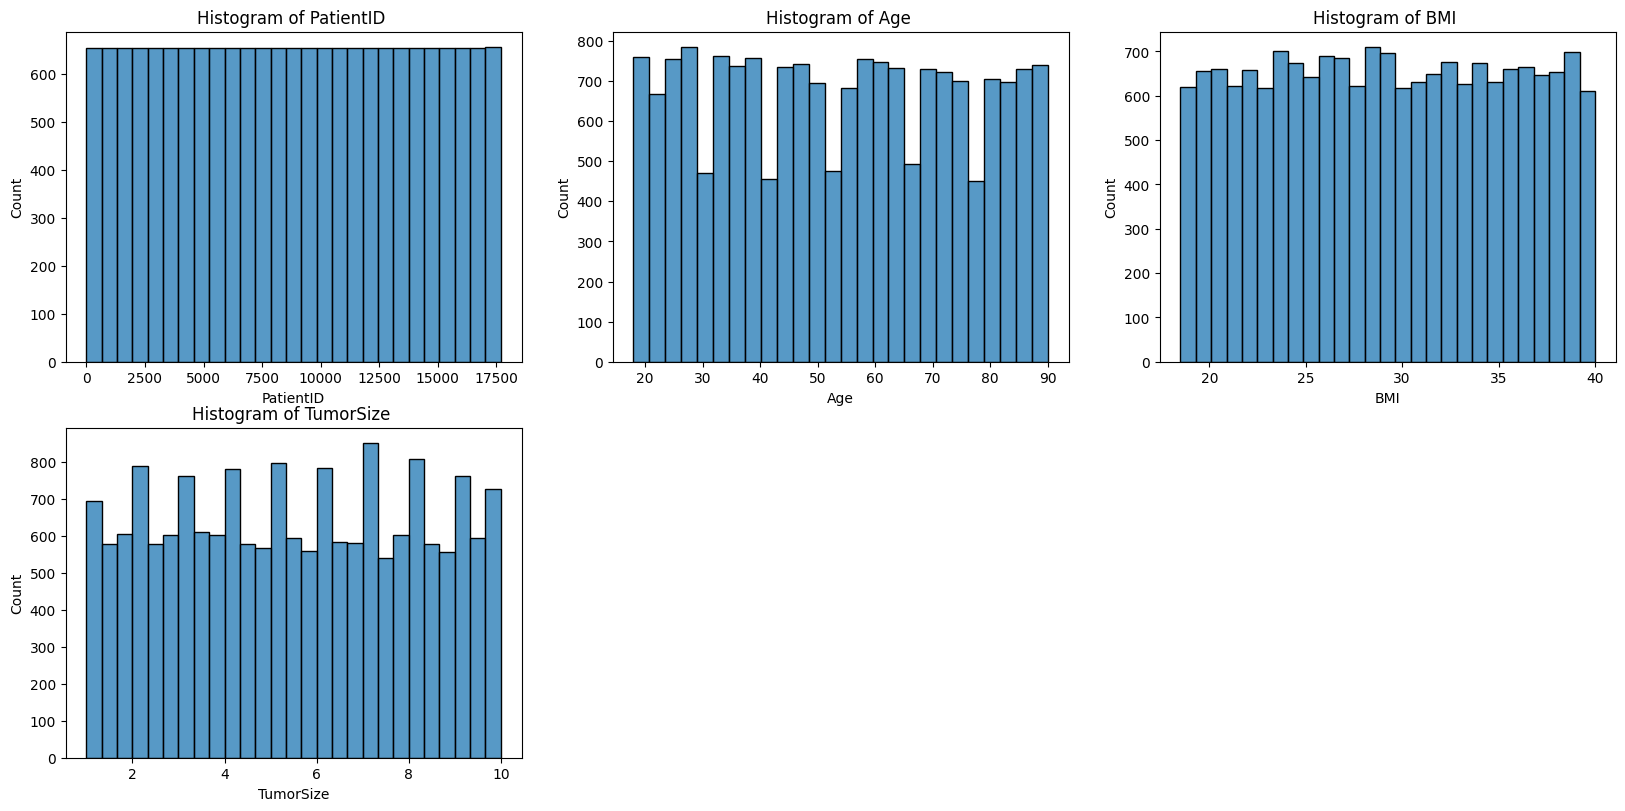

In [ ]:
plt.figure(figsize = (20, 30))
for i, col in enumerate(cencer_numerik.columns[:-1], 1):
    plt.subplot(6, 3, i)
    sns.histplot(x = cencer[col])
    plt.title(f"Histogram of {col} ")
    plt.plot()

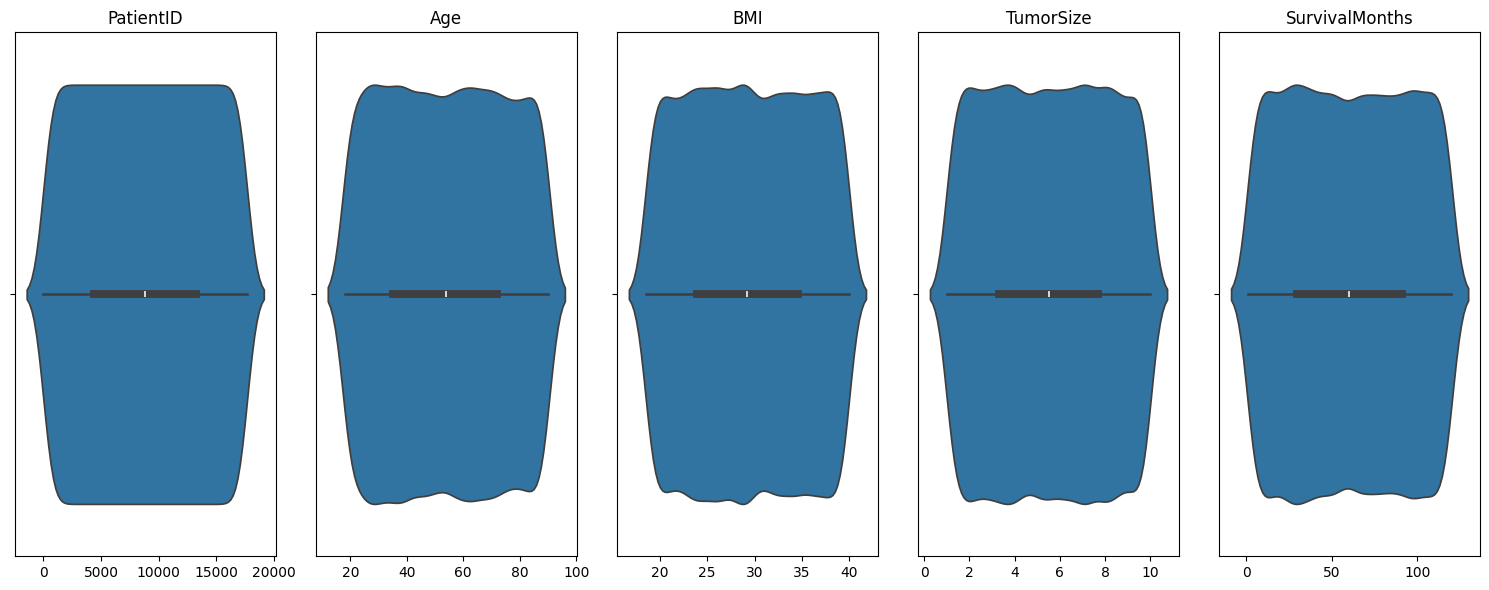

In [ ]:
fig, axes = plt.subplots(ncols=5, figsize=(15, 6))

for i, j in enumerate(cencer_numerik):
    sns.violinplot(cencer, x=j, ax=axes[i])
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")
    axes[i].set_title(j)
plt.tight_layout()
plt.show()

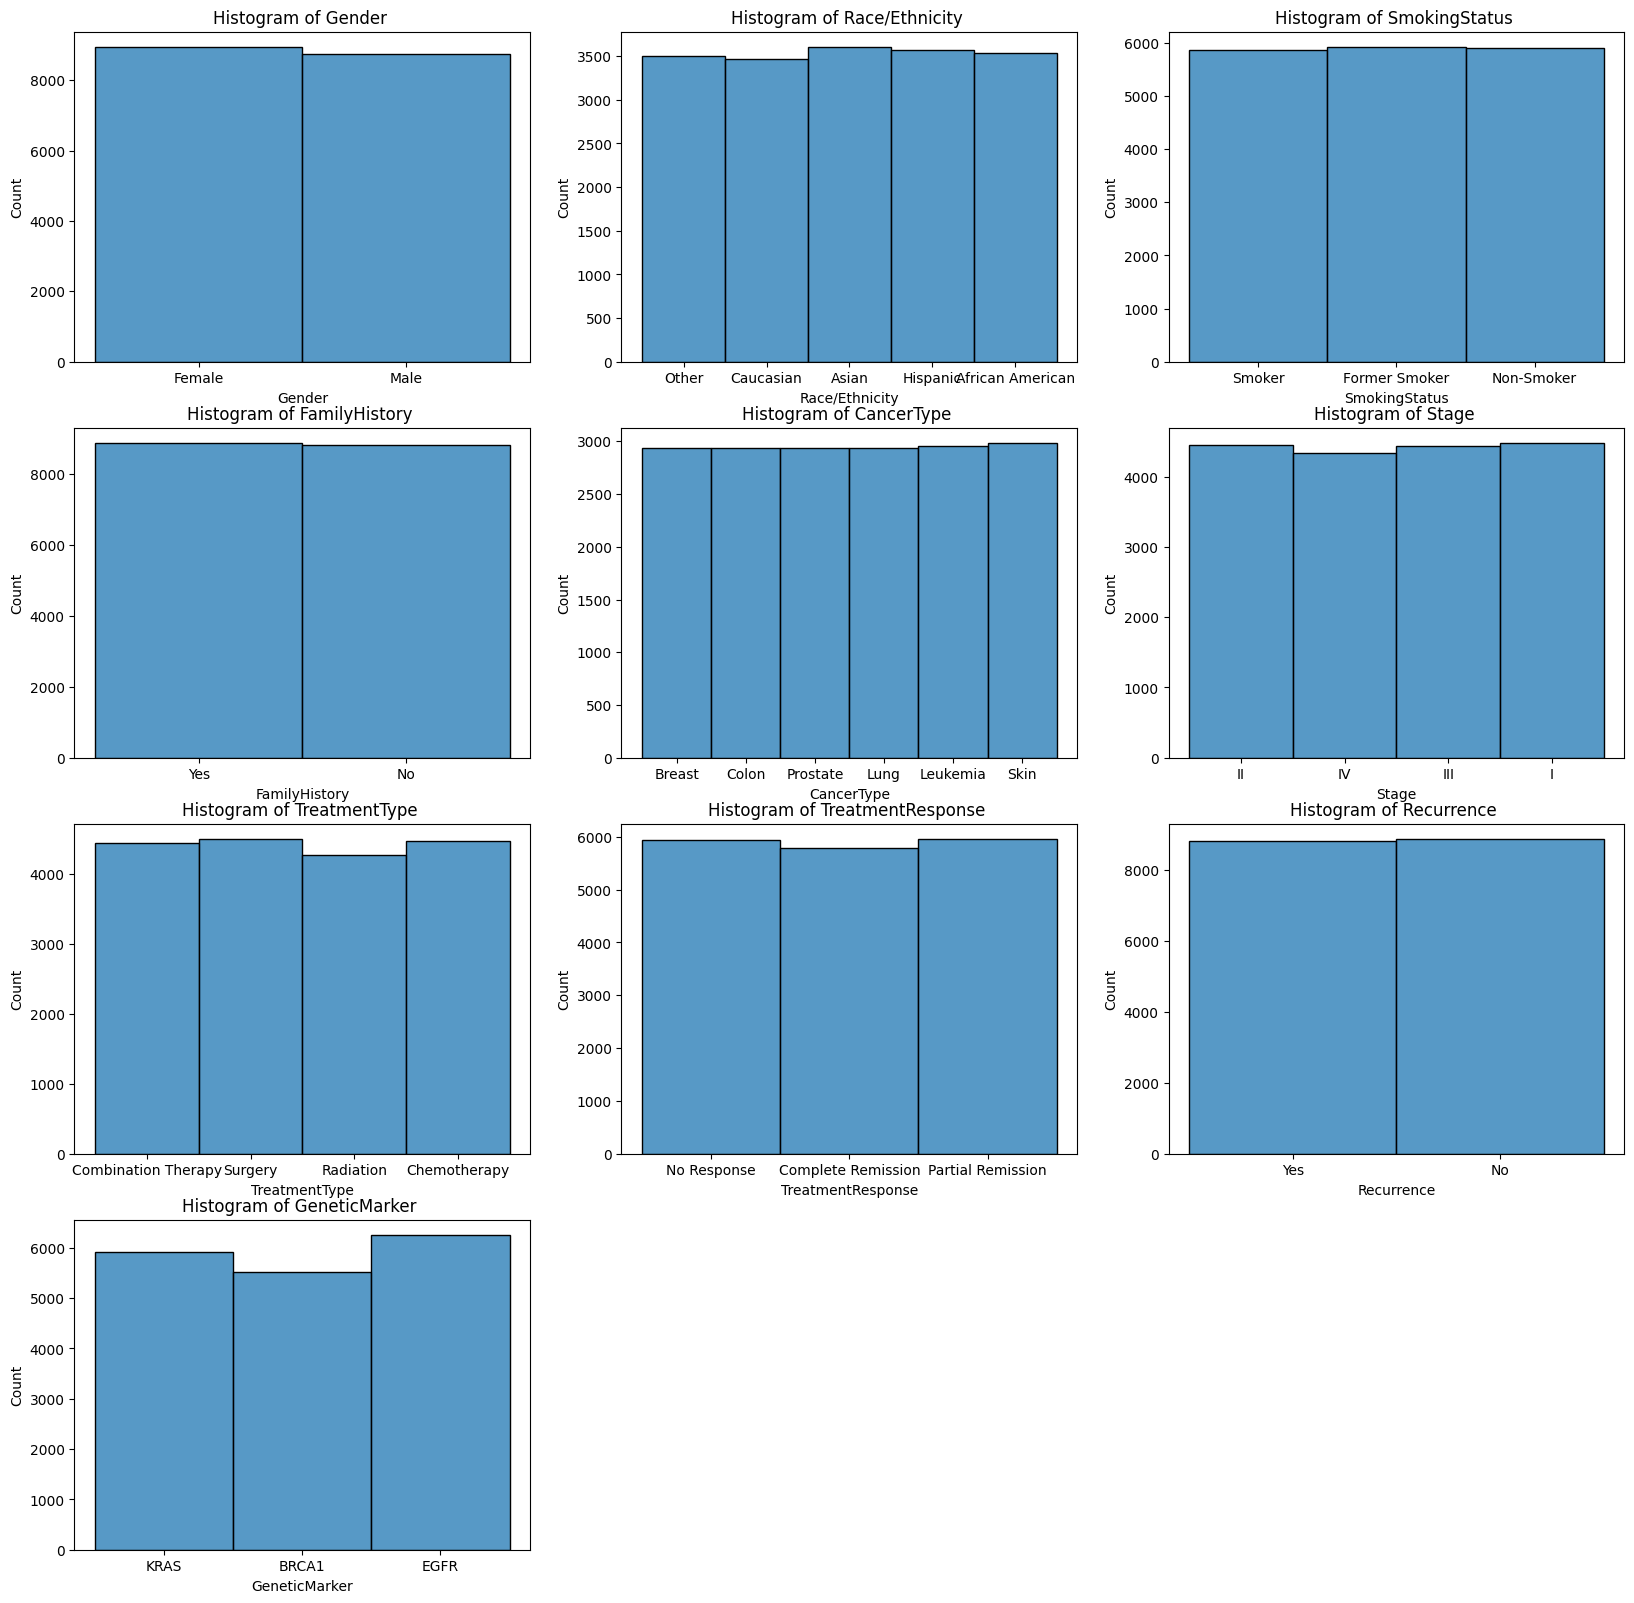

In [ ]:
plt.figure(figsize = (20, 30))
for i, col in enumerate(cencer_kategorikal.columns[:-1], 1):
    plt.subplot(6, 3, i)
    sns.histplot(x = cencer[col])
    plt.title(f"Histogram of {col} ")
    plt.plot()

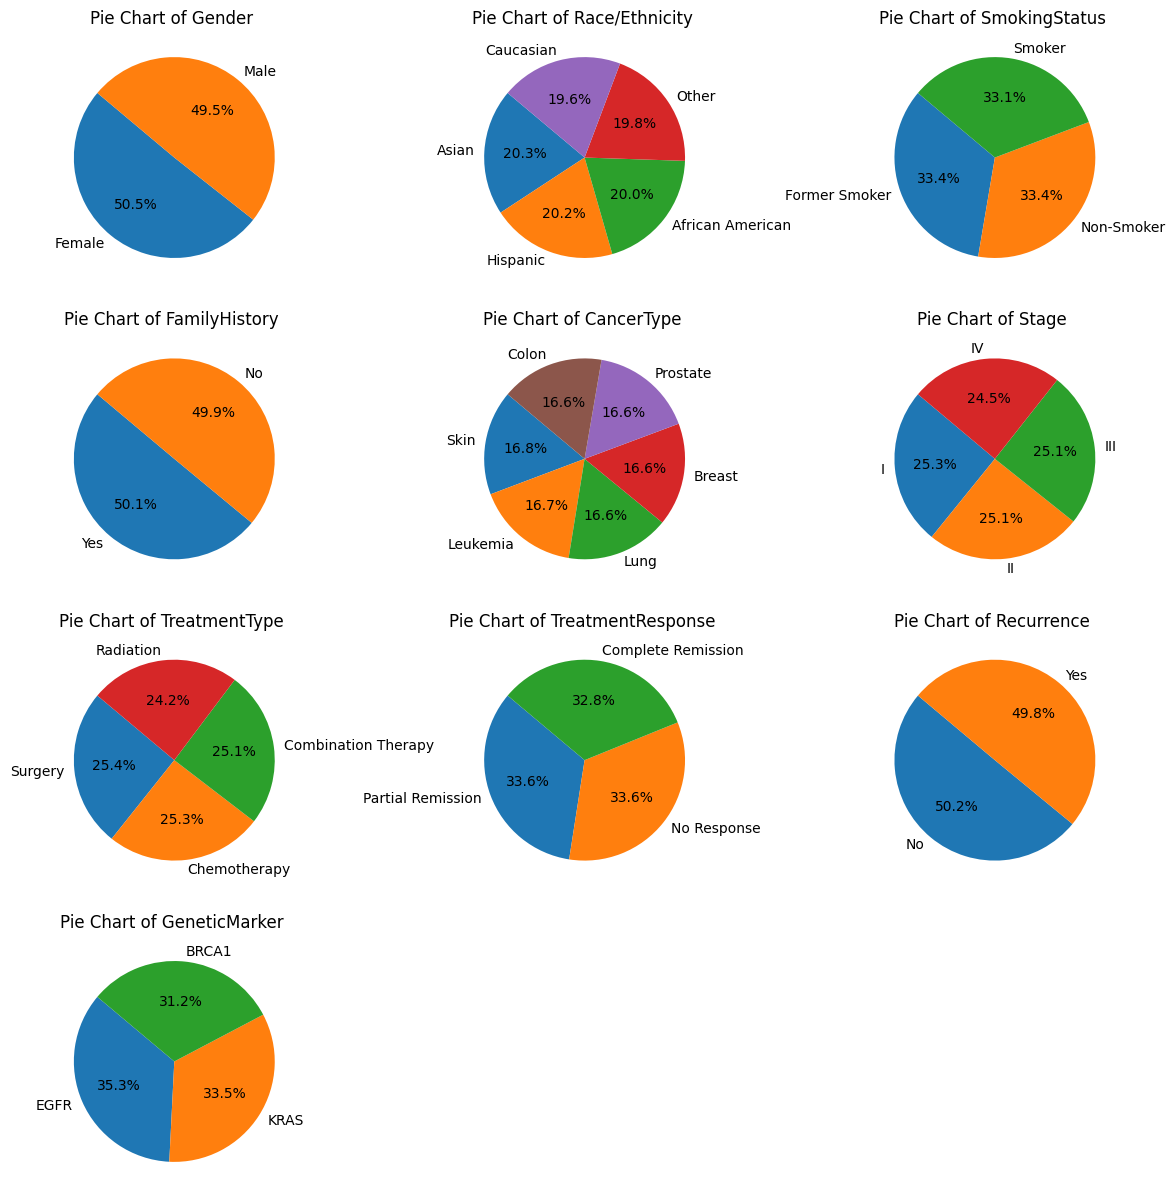

In [ ]:
plt.figure(figsize = (15, 15))
for i, col in enumerate(cencer_kategorikal.columns[:-1], 1):
    plt.subplot(4, 3, i)
    values = cencer[col].value_counts()
    plt.pie(values, labels=values.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"Pie Chart of {col} ")
    plt.plot()

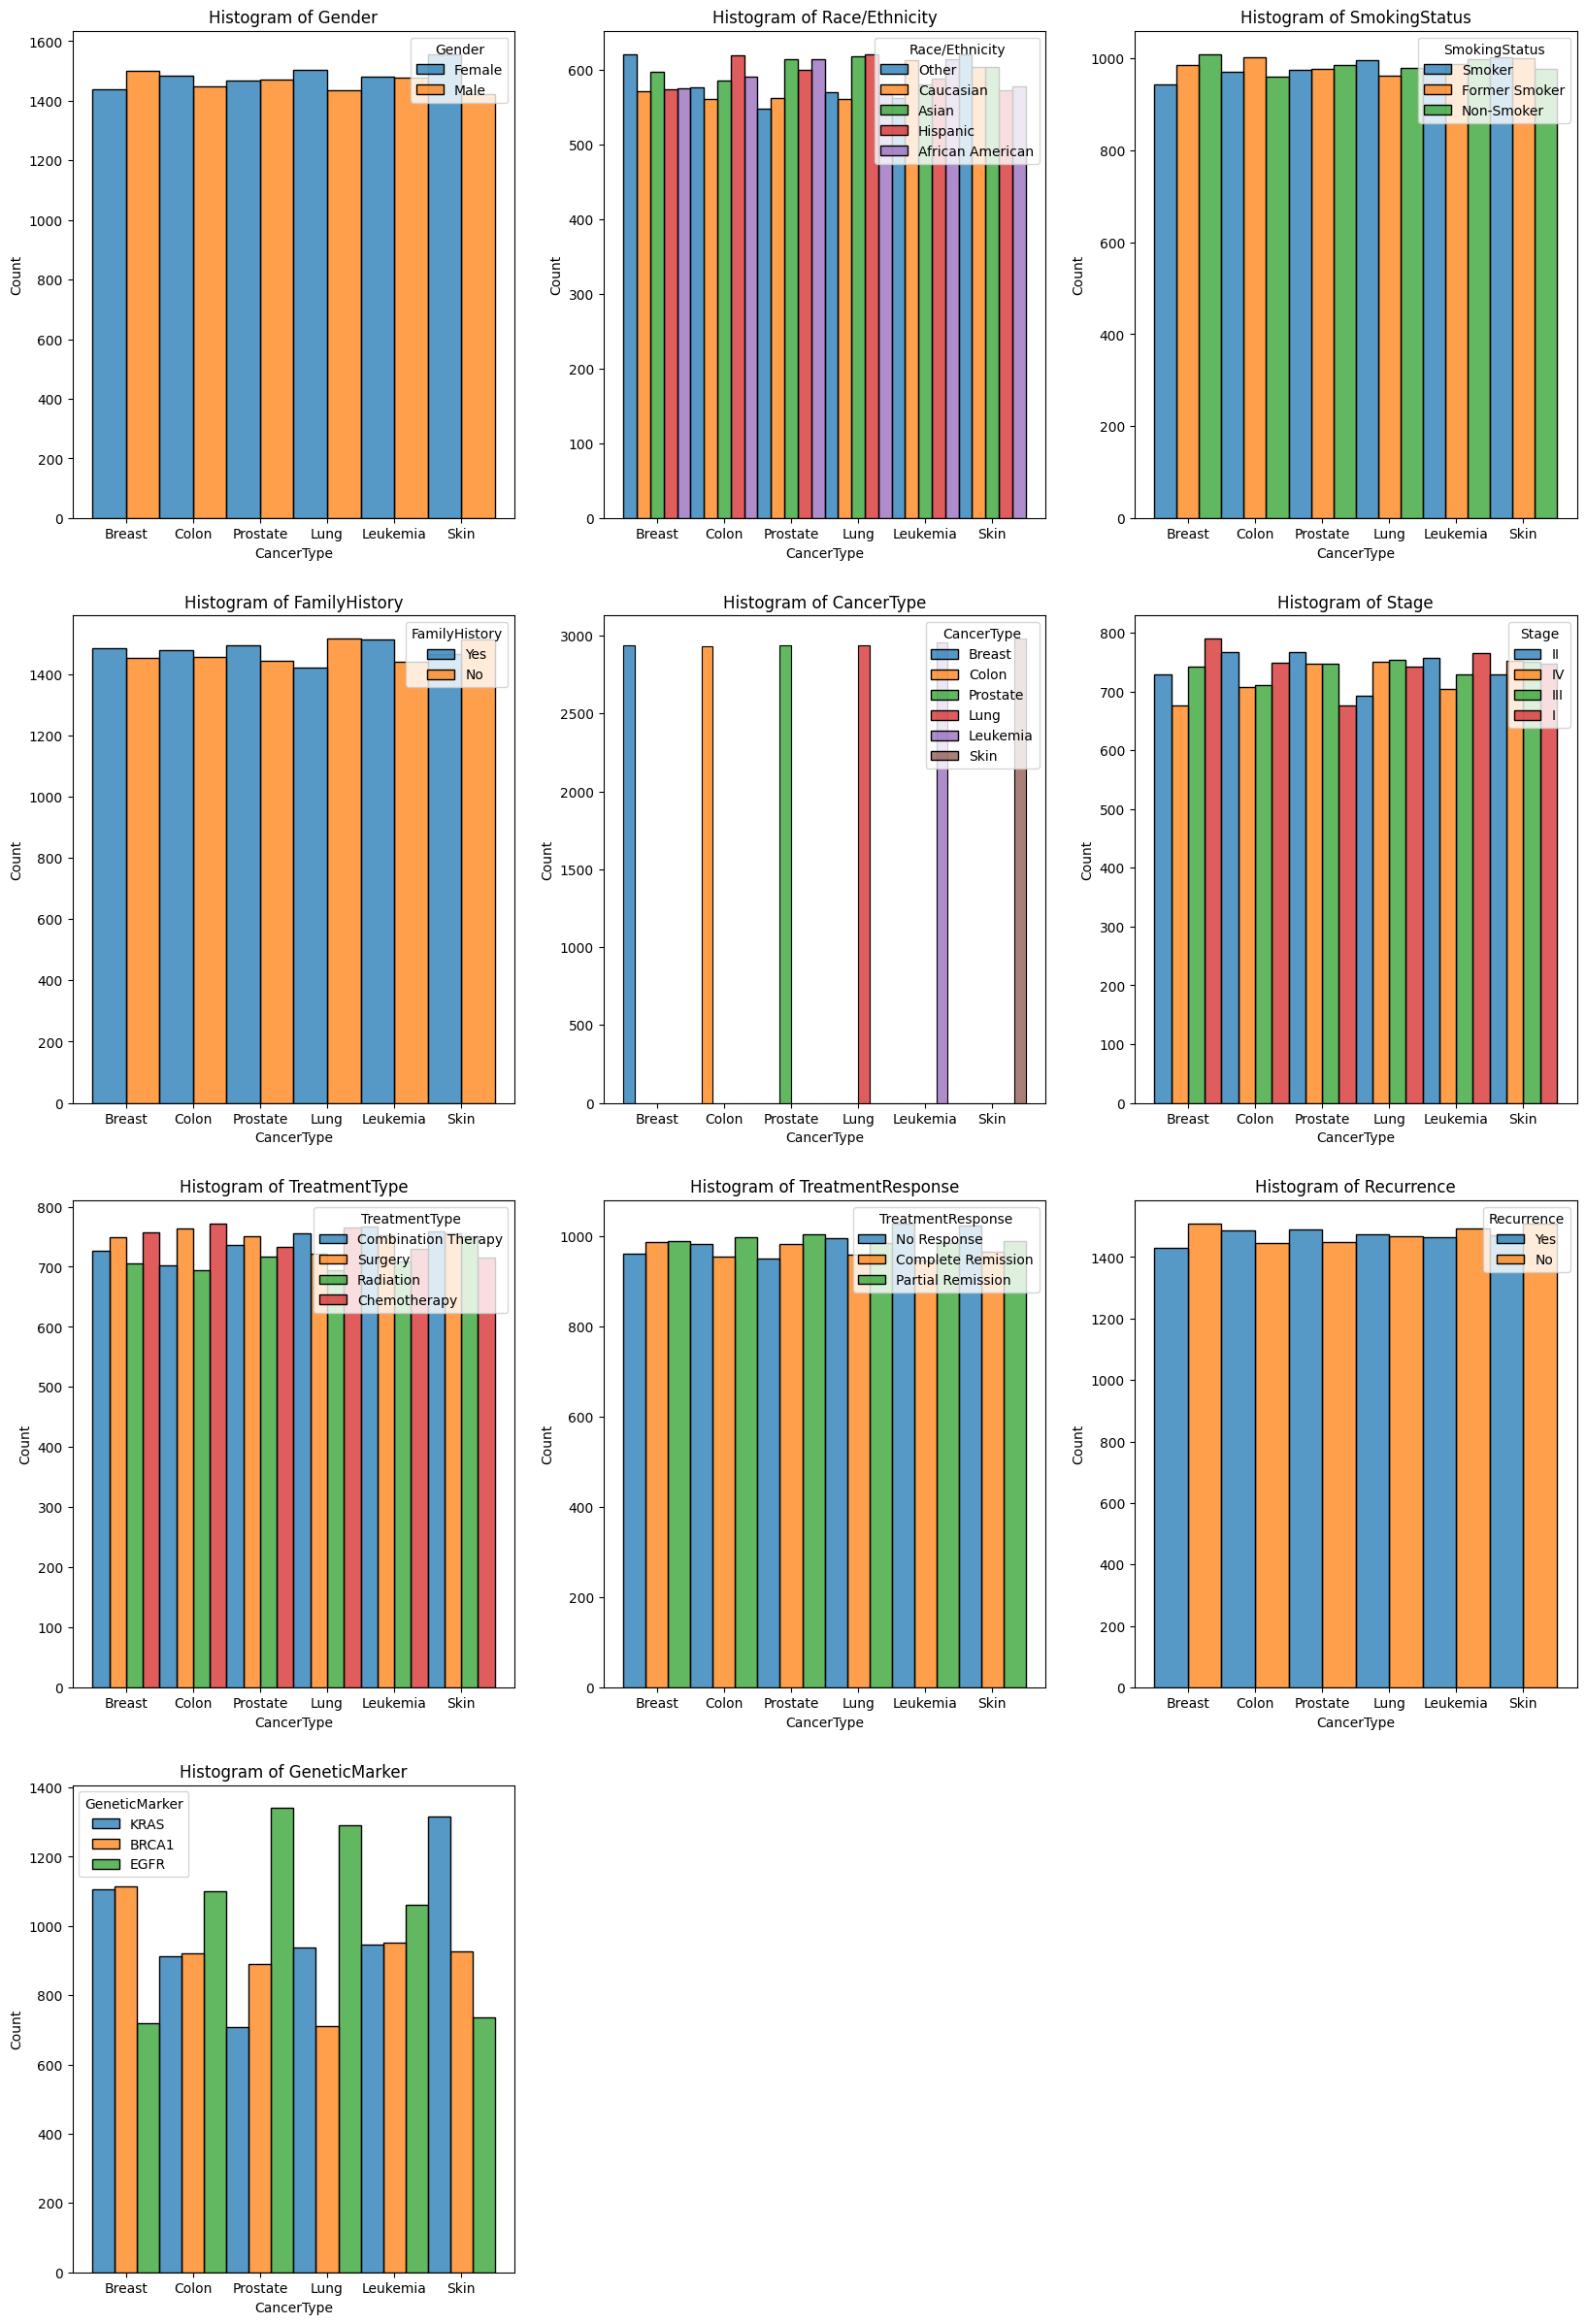

In [ ]:
plt.figure(figsize = (20, 30))
for i, col in enumerate(cencer_kategorikal.columns[:-1], 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=cencer, x="CancerType", hue=col, multiple = "dodge")
    plt.title(f"Histogram of {col}")
    plt.plot()

<Figure size 1200x1200 with 0 Axes>

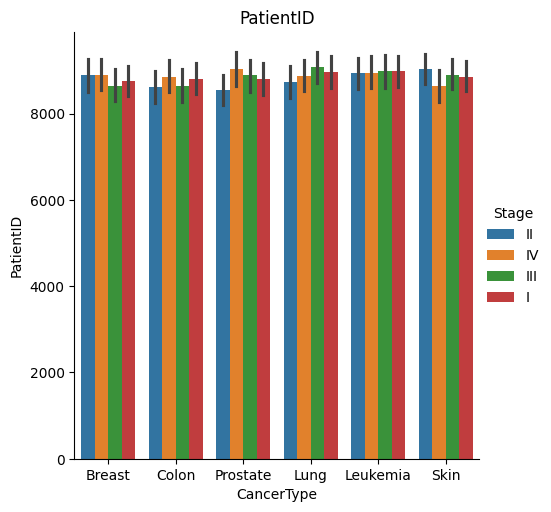

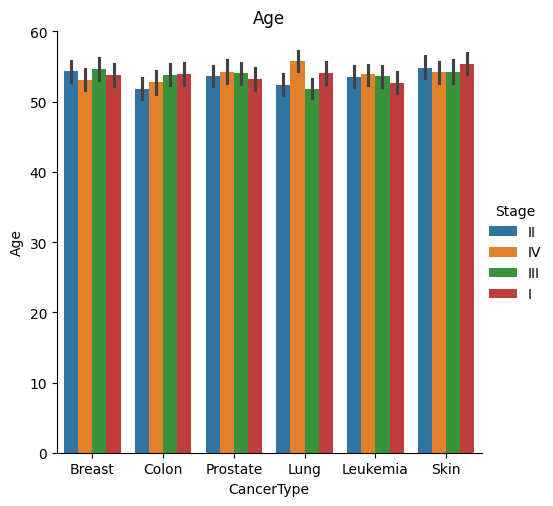

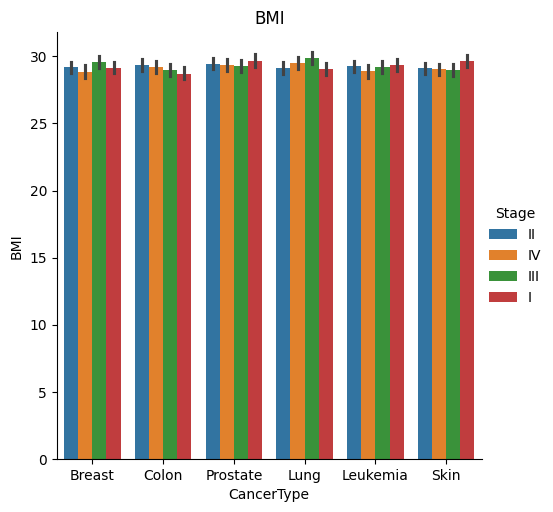

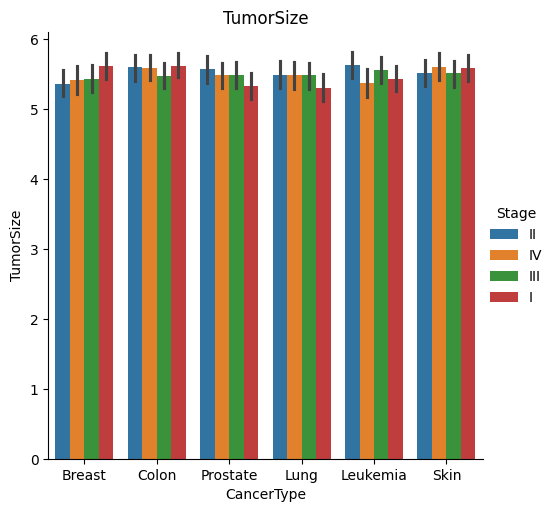

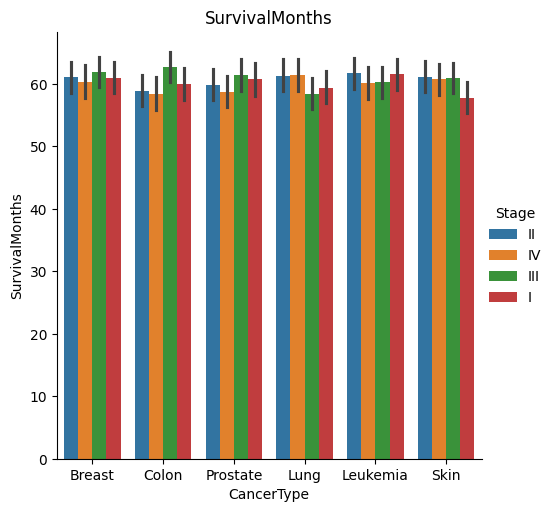

In [ ]:
plt.figure(figsize=(12,12))
for col in cencer_numerik:
    sns.catplot(data=cencer, x="CancerType", y=col, hue="Stage", kind="bar")
    plt.title(f"{col}")
    plt.show()

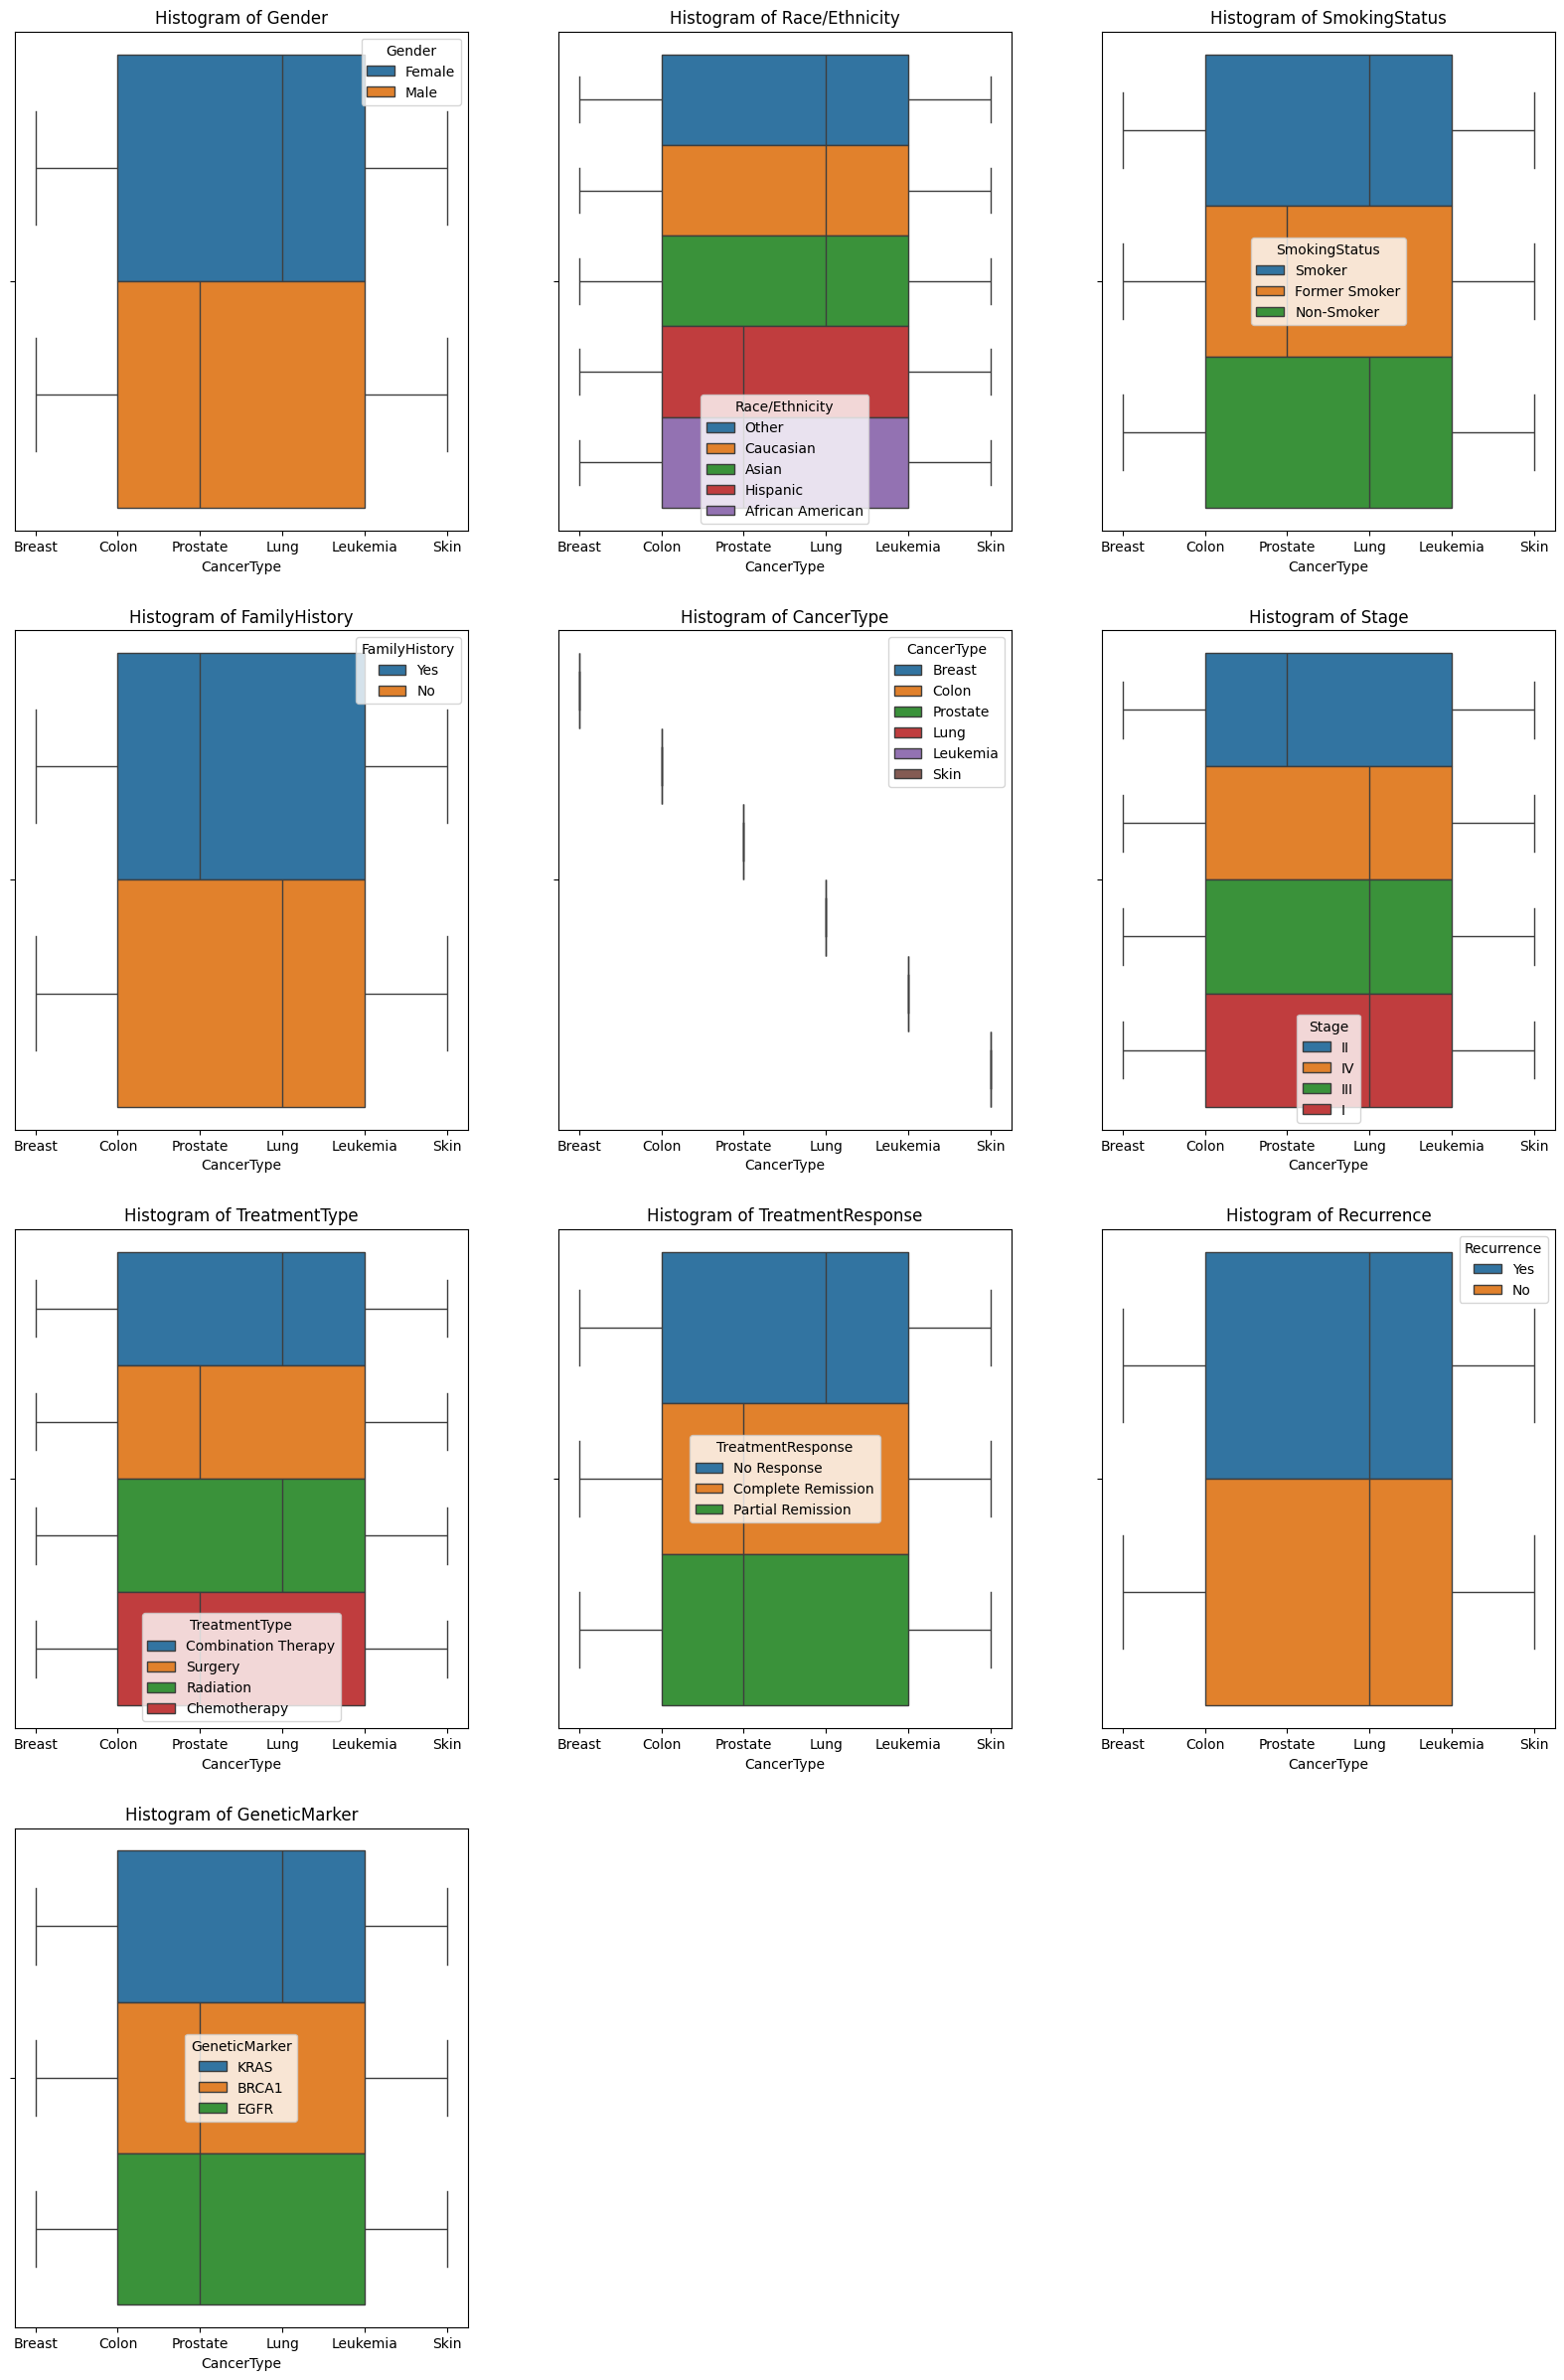

In [ ]:
plt.figure(figsize = (20, 30))
for i, col in enumerate(cencer_kategorikal.columns[:-1], 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=cencer, x="CancerType", hue=col)
    plt.title(f"Histogram of {col}")
    plt.plot()

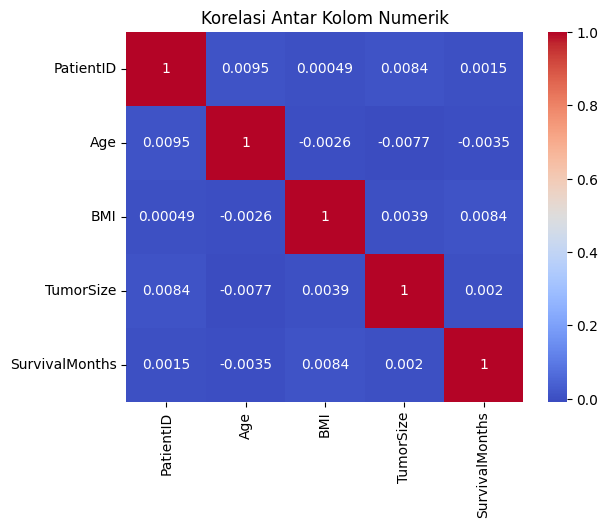

In [ ]:
cnc = cencer_numerik.corr()
sns.heatmap(cnc, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Kolom Numerik')
plt.show()

# **PREPROSESING**

In [ ]:
#merubah nama kolom menjadi huruf kec
cencer.columns = cencer.columns.str.lower()

In [ ]:
#hapus kolom pasien id
cencer = cencer.drop(['patientid'], axis=1)

In [ ]:
#rubah tipedata objek menjadi numerik
le=LabelEncoder()
for col in cencer.select_dtypes(include=['object']).columns:
    cencer[col] = le.fit_transform(cencer[col])
cencer.head(5)

,age,gender,race/ethnicity,bmi,smokingstatus,familyhistory,cancertype,stage,tumorsize,treatmenttype,treatmentresponse,survivalmonths,recurrence,geneticmarker,hospitalregion
0,80,0,4,23.3,2,1,0,1,1.7,1,1,103,1,2,2
1,76,1,2,22.4,0,1,1,3,4.7,3,1,14,1,0,3
2,69,1,1,21.5,2,1,0,2,8.3,1,0,61,1,0,3
3,77,1,1,30.4,0,1,4,1,1.7,2,2,64,0,2,2
4,89,1,2,20.9,2,1,3,3,7.4,2,1,82,1,2,2


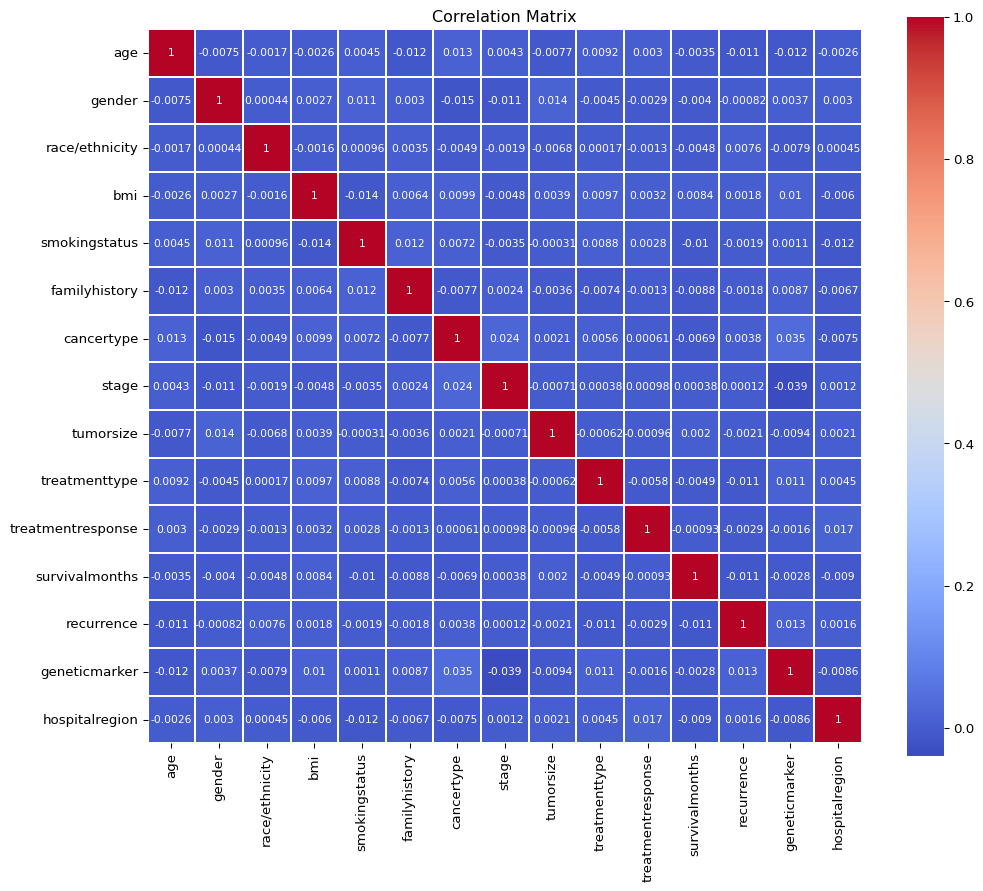

In [ ]:
#kode korelasi dataset
plt.figure(figsize=(12,10),dpi=96)
sns.heatmap(cencer.corr(), annot=True, cmap='coolwarm', linewidths=0.1, square=True, annot_kws={"fontsize":8})
plt.title('Correlation Matrix')
plt.show()

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, StandardScaler, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, MultilayerPerceptronClassifier, LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Inisialisasi sesi Spark
spark = SparkSession.builder.appName("CancerPrediction").getOrCreate()

In [ ]:
# Konversi pandas DataFrame 'cencer' ke Spark DataFrame 'data'
data = spark.createDataFrame(cencer)

In [ ]:
# String Indexing untuk kolom kategori
indexers = [
    StringIndexer(inputCol=column, outputCol=column + "_index")
    for column in ['gender', 'race/ethnicity', 'smokingstatus', 'familyhistory', 'cancertype', 'stage', 'recurrence', 'geneticmarker', 'hospitalregion', 'treatmentresponse']
]

In [ ]:
# Pipeline untuk indexing
indexing_pipeline = Pipeline(stages=indexers)
data = indexing_pipeline.fit(data).transform(data)

In [ ]:
# Menambahkan kolom label biner untuk model biner
data = data.withColumn("TreatmentResponse_binary", when(data["TreatmentResponse_index"] <= 1, 0).otherwise(1))

# Menormalkan label untuk MultilayerPerceptronClassifier agar berada dalam {0, 1}
data = data.withColumn("TreatmentResponse_index", when(data["TreatmentResponse_index"] > 1, 1).otherwise(data["TreatmentResponse_index"]))

In [ ]:
# Menggabungkan fitur
assembler = VectorAssembler(
    inputCols=['age', 'bmi', 'tumorsize'] + [col + "_index" for col in ['gender', 'race/ethnicity', 'smokingstatus', 'familyhistory', 'cancertype', 'stage', 'recurrence', 'geneticmarker', 'hospitalregion']],
    outputCol="features"
)

In [ ]:
# Standarisasi fitur
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

# **LATIH MODEL & EVALUASI**

In [ ]:
# Mendefinisikan model
rf = RandomForestClassifier(labelCol="TreatmentResponse_index", featuresCol="scaledFeatures", seed=42)
gbt = GBTClassifier(labelCol="TreatmentResponse_binary", featuresCol="scaledFeatures", seed=42)
mlp = MultilayerPerceptronClassifier(labelCol="TreatmentResponse_index", featuresCol="scaledFeatures", layers=[len(assembler.getInputCols()), 10, 5, 2], seed=42)
svc = LinearSVC(labelCol="TreatmentResponse_binary", featuresCol="scaledFeatures", maxIter=100, regParam=0.1)

In [ ]:
# Pipeline
pipelines = {
    "Random Forest": Pipeline(stages=[assembler, scaler, rf]),
    "Gradient Boosting": Pipeline(stages=[assembler, scaler, gbt]),
    "MLP": Pipeline(stages=[assembler, scaler, mlp]),
    "Linear SVC": Pipeline(stages=[assembler, scaler, svc])
}

In [ ]:
# Membagi data menjadi data latih dan data uji
train, test = data.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Evaluasi model dengan metrik tambahan
results = []

for name, pipeline in pipelines.items():
    # Menentukan evaluator yang sesuai dengan label
    label_col = "TreatmentResponse_binary" if pipeline.getStages()[-1].getLabelCol() == "TreatmentResponse_binary" else "TreatmentResponse_index"
    evaluator_accuracy = MulticlassClassificationEvaluator(labelCol=label_col, metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol=label_col, metricName="f1")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol=label_col, metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol=label_col, metricName="weightedRecall")

    # Melatih model
    model = pipeline.fit(train)

    # Membuat prediksi
    predictions = model.transform(test)

    # Menghitung metrik
    accuracy = evaluator_accuracy.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    # Menyimpan hasil
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Precision": precision,
        "Recall": recall
    })

# **VISUALISASI HASIL**

In [ ]:
# Konversi hasil ke DataFrame untuk visualisasi
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy  F1 Score  Precision    Recall
0      Random Forest  0.666570  0.533209   0.444315  0.666570
1  Gradient Boosting  0.664826  0.540057   0.615353  0.664826
2                MLP  0.665988  0.537135   0.592896  0.665988
3         Linear SVC  0.664535  0.530607   0.441607  0.664535


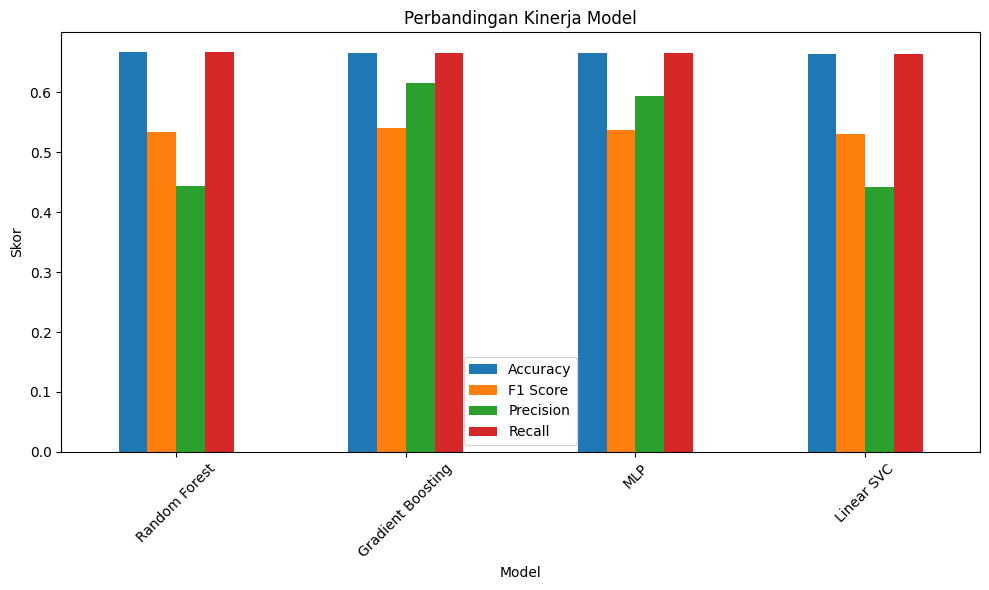

In [ ]:
# Membuat plot
fig, ax = plt.subplots(figsize=(10, 6))
results_df.set_index("Model").plot(kind="bar", ax=ax)
plt.title("Perbandingan Kinerja Model")
plt.ylabel("Skor")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# **HYPERMATER TUNING**

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
# Pipeline untuk masing-masing model
mlp_pipeline = Pipeline(stages=[assembler, scaler, mlp])
gbt_pipeline = Pipeline(stages=[assembler, scaler, gbt])

In [ ]:
# Membagi data menjadi data latih dan data uji
train, test = data.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Hyperparameter tuning untuk MLP
mlp_param_grid = (ParamGridBuilder()
    .addGrid(mlp.layers, [[len(assembler.getInputCols()), 10, 5, 2], [len(assembler.getInputCols()), 20, 10, 2]])
    .addGrid(mlp.maxIter, [100, 200])
    .build())

mlp_cv = CrossValidator(
    estimator=mlp_pipeline,
    estimatorParamMaps=mlp_param_grid,
    evaluator=MulticlassClassificationEvaluator(labelCol="TreatmentResponse_index", metricName="accuracy"),
    numFolds=3
)

In [ ]:
# Hyperparameter tuning untuk GBT
gbt_param_grid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5, 7])
    .addGrid(gbt.maxIter, [20, 50, 100])
    .build())

gbt_cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_param_grid,
    evaluator=MulticlassClassificationEvaluator(labelCol="TreatmentResponse_binary", metricName="accuracy"),
    numFolds=3
)

In [ ]:
# Melakukan cross-validation untuk MLP dan GBT
print("Training MLP model with hyperparameter tuning...")
mlp_model = mlp_cv.fit(train)
print("Best MLP model parameters:", mlp_model.bestModel.stages[-1].extractParamMap())

print("Training GBT model with hyperparameter tuning...")
gbt_model = gbt_cv.fit(train)
print("Best GBT model parameters:", gbt_model.bestModel.stages[-1].extractParamMap())

Training MLP model with hyperparameter tuning...
Best MLP model parameters: {Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='blockSize', doc='block size for stacking input data in matrices. Data is stacked within partitions. If block size is more than remaining data in a partition then it is adjusted to the size of this data.'): 128, Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='featuresCol', doc='features column name.'): 'scaledFeatures', Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='labelCol', doc='label column name.'): 'TreatmentResponse_index', Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='maxIter', doc='max number of iterations (>= 0).'): 100, Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='predictionCol', doc='prediction column name.'): 'prediction', Param(parent='MultilayerPerceptronClassifier_7ba51a70c8ff', name='probabilityCol', doc='Column name for predicted class conditional proba

EVALUASI DAN VISUALISASI

In [ ]:
# Membuat prediksi dengan model terbaik
mlp_predictions = mlp_model.transform(test)
gbt_predictions = gbt_model.transform(test)

In [ ]:
# Evaluasi dengan beberapa metrik
def evaluasi_model(prediksi, kolom_label):
    """Mengevaluasi model menggunakan beberapa metrik."""
    evaluator_akurasi = MulticlassClassificationEvaluator(labelCol=kolom_label, metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol=kolom_label, metricName="f1")
    evaluator_presisi = MulticlassClassificationEvaluator(labelCol=kolom_label, metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol=kolom_label, metricName="weightedRecall")

    # Untuk AUC, gunakan BinaryClassificationEvaluator jika label biner
    if kolom_label == "TreatmentResponse_binary":
        evaluator_auc = BinaryClassificationEvaluator(labelCol=kolom_label, metricName="areaUnderROC")
        auc = evaluator_auc.evaluate(prediksi)
    else:
        auc = None  # AUC tidak berlaku untuk multiclass dalam konteks ini

    akurasi = evaluator_akurasi.evaluate(prediksi)
    f1 = evaluator_f1.evaluate(prediksi)
    presisi = evaluator_presisi.evaluate(prediksi)
    recall = evaluator_recall.evaluate(prediksi)

    return akurasi, f1, presisi, recall, auc

In [ ]:
# Evaluasi model yang telah di-tuning
mlp_akurasi, mlp_f1, mlp_presisi, mlp_recall, mlp_auc = evaluasi_model(mlp_predictions, "TreatmentResponse_index")
gbt_akurasi, gbt_f1, gbt_presisi, gbt_recall, gbt_auc = evaluasi_model(gbt_predictions, "TreatmentResponse_binary")

# Simpan hasil dalam DataFrame
hasil = pd.DataFrame({
    "Model": ["MLP", "GBT"],
    "Akurasi": [mlp_akurasi, gbt_akurasi],
    "F1 Score": [mlp_f1, gbt_f1],
    "Presisi": [mlp_presisi, gbt_presisi],
    "Recall": [mlp_recall, gbt_recall],
    "AUC": [mlp_auc, gbt_auc]
})


print(hasil)

  Model   Akurasi  F1 Score   Presisi    Recall       AUC
0   MLP  0.665988  0.537135  0.592896  0.665988       NaN
1   GBT  0.664244  0.530467  0.441542  0.664244  0.497782


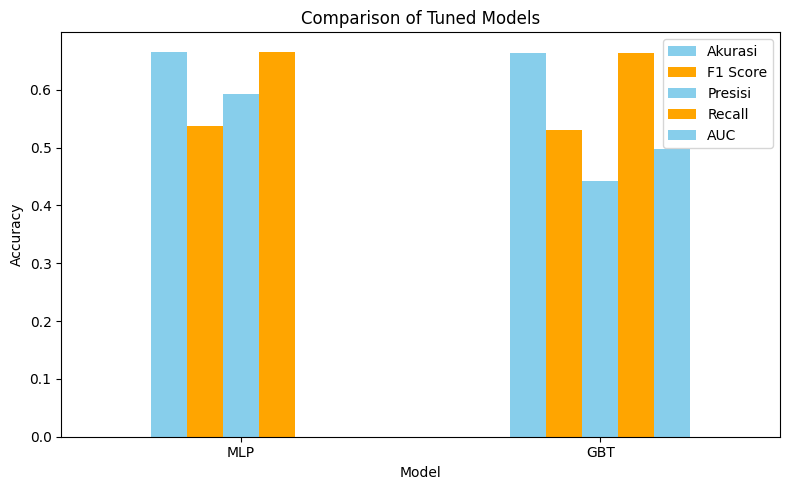

In [ ]:
# Membuat plot hasil
fig, ax = plt.subplots(figsize=(8, 5))
hasil.set_index("Model").plot(kind="bar", ax=ax, color=['skyblue', 'orange'])
plt.title("Comparison of Tuned Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Menghentikan sesi Spark
spark.stop()